In [1]:
import numpy as np
import matplotlib.pyplot as plt
a = np.array([1, 2, 3])
b = np.array([4, 5, 7])
c = np.stack((a, b), axis=0)
d = np.stack((c, c), axis=0)
d.shape


(2, 2, 3)

In [4]:
# find the position
np.random.seed(0)
a = np.random.randn(3, 4)
b = np.random.randn(3, 4)
print(a, b)
c = np.zeros((3, 4))
c[a > b] = 1
c[a < b] = -1
c[a == b] = 0
print(c)
print(np.sign(a - b))

[[ 1.76405235  0.40015721  0.97873798  2.2408932 ]
 [ 1.86755799 -0.97727788  0.95008842 -0.15135721]
 [-0.10321885  0.4105985   0.14404357  1.45427351]] [[ 0.76103773  0.12167502  0.44386323  0.33367433]
 [ 1.49407907 -0.20515826  0.3130677  -0.85409574]
 [-2.55298982  0.6536186   0.8644362  -0.74216502]]
[[ 1.  1.  1.  1.]
 [ 1. -1.  1.  1.]
 [ 1. -1. -1.  1.]]
[[ 1.  1.  1.  1.]
 [ 1. -1.  1.  1.]
 [ 1. -1. -1.  1.]]


In [ ]:
# np.gradient
np.gradient(c, axis=1)      # 沿axis做diff，内点使用中心差分，边界默认使用一阶差分

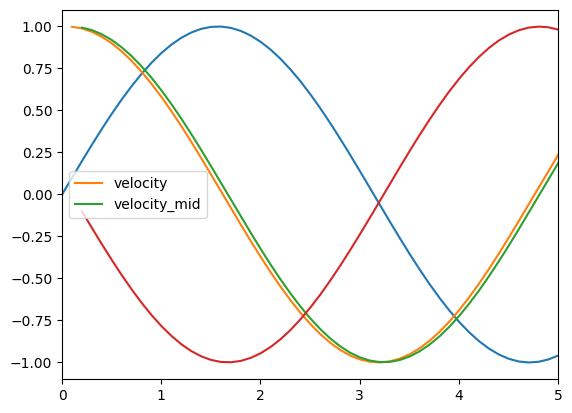

In [20]:
# 中心差分计算速度
time = np.linspace(0, 100, 1000)
position = np.sin(time)
# 一阶差分
velocity = np.diff(position)/np.diff(time)[0]
# 二阶中心差分
velocity_mid = position[2:] - position[:-2]
velocity_mid /= time[2:] - time[:-2]
# 二阶差分
acceleration = np.diff(position, 2)/np.diff(time)[0]/np.diff(time)[0]
plt.plot(time, position)
plt.plot(time[1:], velocity, label='velocity')
plt.plot(time[2:], velocity_mid, label='velocity_mid')
plt.plot(time[2:], acceleration)
plt.xlim(0, 5)
plt.legend()

In [3]:
# 进化算法
from scipy.optimize import differential_evolution

def error_to_minimize(params):
    c1, c2 = params
    return (c1 - 500)**2 + (c2 - 320.1212)**2  # 示例

bounds = [(0, 1000), (0, 1000)]  # c1, c2 的范围

result = differential_evolution(error_to_minimize, bounds, strategy='best1bin', maxiter=1000)

best_c1, best_c2 = result.x
print(f"最优参数: c1={best_c1}, c2={best_c2}, error={result.fun}")

最优参数: c1=500.0, c2=320.1212, error=0.0


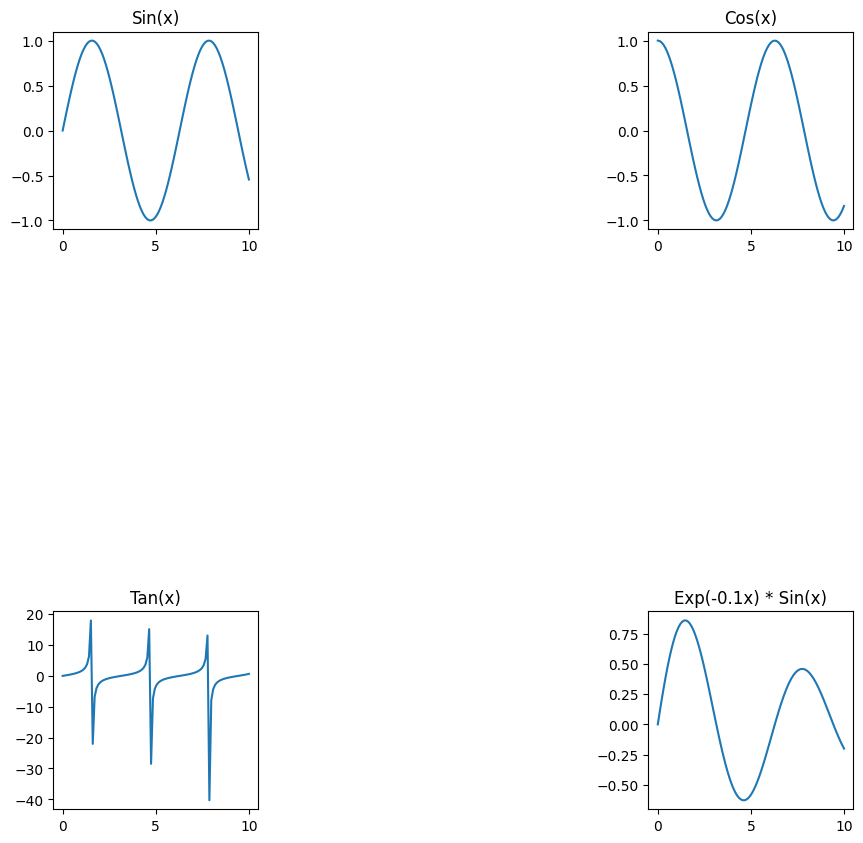

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# 示例数据
x = np.linspace(0, 10, 100)
y1, y2, y3, y4 = np.sin(x), np.cos(x), np.tan(x), np.exp(-0.1 * x) * np.sin(x)

# 创建图像，设置figsize
fig = plt.figure(figsize=(8, 8))

# 创建 2x2 的网格布局
gs = GridSpec(2, 2, figure=fig)

# 创建四个子图
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# 绘制数据
ax1.plot(x, y1)
ax2.plot(x, y2)
ax3.plot(x, y3)
ax4.plot(x, y4)

# 设置标题
ax1.set_title('Sin(x)')
ax2.set_title('Cos(x)')
ax3.set_title('Tan(x)')
ax4.set_title('Exp(-0.1x) * Sin(x)')

# 获取 ax2 的位置和尺寸
position_ax2 = ax2.get_position()

# 强制其他图的大小与 ax2 相同
ax1.set_position(position_ax2)
ax3.set_position(position_ax2)
ax4.set_position(position_ax2)

# 设置每个子图的纵横比为相等的正方形
# for ax in [ax1]:
#     ax.set_aspect('equal', adjustable='box')

# 调整布局，确保子图尺寸一致
fig.tight_layout(pad=0)

plt.show()